# 01 -- Sensor Overview & Dataset Exploration

This notebook provides a first look at the **AQUINAS dataset**:

- Load a monthly dataset (SET1) and inspect the 48 sensors
- Read a single event record and plot the raw waveform
- Visualise all 48 sensors side-by-side for a chosen event
- Overlay all sensor waveforms on one plot

**Attribution:** The original exploratory analysis was developed by
Zhenkun Li. This notebook is a cleaned and restructured version
using the `aquinas_toolkit` package.

In [3]:
from pathlib import Path

from IPython.display import display

from aquinas_toolkit import AquinasReader, plot_waveform, plot_sensor_grid, plot_sensor_overlay

## Load a dataset

Point `dataset_dir` at any of the five monthly SET folders.
The dataset is not committed to git -- place it at
`AQUINAS_DATASET/` in the repo root.

## Z-acceleration record inventory across all monthly sets

The next cell builds a clean table for every monthly dataset, restricted to
vertical acceleration channels (`ACC_Z`). Each table lists the deck, span,
side, and location of each sensor together with the number of indexed
recordings found in that monthly SET.

In [4]:
dataset_root = Path("../AQUINAS_DATASET")
set_dirs = sorted(dataset_root.glob("AQUINAS_SET*"))

for set_dir in set_dirs:
    set_reader = AquinasReader(set_dir)
    z_counts = set_reader.summarize_sensor_records(quantity="ACC", axis="Z")
    table = z_counts[["deck", "span", "side", "location", "sensor_name", "record_count"]].rename(
        columns={
            "deck": "Deck",
            "span": "Span",
            "side": "Side",
            "location": "Location",
            "sensor_name": "Sensor",
            "record_count": "Recordings",
        }
    )
    styled = (
        table.style.hide(axis="index")
        .format({"Recordings": "{:,.0f}"})
        .set_caption(f"{set_reader.set_name} — Z-Acceleration Record Inventory")
    )

    display(styled)
    summary = (
        z_counts.groupby(["deck", "span", "location"], as_index=False)["record_count"]
        .sum()
        .rename(
            columns={
                "deck": "Deck",
                "span": "Span",
                "location": "Location",
                "record_count": "Recordings",
            }
        )
    )
    display(
        summary.style.hide(axis="index")
        .format({"Recordings": "{:,.0f}"})
        .set_caption(f"{set_reader.set_name} — Z-Acceleration Totals by Deck, Span, and Location")
    )

Deck,Span,Side,Location,Sensor,Recordings
NEW,S1,DO,INT,NEW_S1_DO_INT_ACC_Z,"3,632"
NEW,S1,DO,MID,NEW_S1_DO_MID_ACC_Z,"3,632"
NEW,S1,UP,INT,NEW_S1_UP_INT_ACC_Z,"3,633"
NEW,S1,UP,MID,NEW_S1_UP_MID_ACC_Z,"3,633"
NEW,S2,DO,INT,NEW_S2_DO_INT_ACC_Z,"3,632"
NEW,S2,DO,MID,NEW_S2_DO_MID_ACC_Z,"3,632"
NEW,S2,UP,INT,NEW_S2_UP_INT_ACC_Z,"3,633"
NEW,S2,UP,MID,NEW_S2_UP_MID_ACC_Z,"3,633"
OLD,S1,DO,INT,OLD_S1_DO_INT_ACC_Z,"3,948"
OLD,S1,DO,MID,OLD_S1_DO_MID_ACC_Z,"3,948"


Deck,Span,Location,Recordings
NEW,S1,INT,"7,265"
NEW,S1,MID,"7,265"
NEW,S2,INT,"7,265"
NEW,S2,MID,"7,265"
OLD,S1,INT,"7,894"
OLD,S1,MID,"7,895"
OLD,S2,INT,"7,895"
OLD,S2,MID,"7,895"


Deck,Span,Side,Location,Sensor,Recordings
NEW,S1,DO,INT,NEW_S1_DO_INT_ACC_Z,"1,678"
NEW,S1,DO,MID,NEW_S1_DO_MID_ACC_Z,"1,678"
NEW,S1,UP,INT,NEW_S1_UP_INT_ACC_Z,"1,678"
NEW,S1,UP,MID,NEW_S1_UP_MID_ACC_Z,"1,678"
NEW,S2,DO,INT,NEW_S2_DO_INT_ACC_Z,"1,678"
NEW,S2,DO,MID,NEW_S2_DO_MID_ACC_Z,"1,678"
NEW,S2,UP,INT,NEW_S2_UP_INT_ACC_Z,"1,678"
NEW,S2,UP,MID,NEW_S2_UP_MID_ACC_Z,"1,678"
OLD,S1,DO,INT,OLD_S1_DO_INT_ACC_Z,"2,105"
OLD,S1,DO,MID,OLD_S1_DO_MID_ACC_Z,"2,105"


Deck,Span,Location,Recordings
NEW,S1,INT,"3,356"
NEW,S1,MID,"3,356"
NEW,S2,INT,"3,356"
NEW,S2,MID,"3,356"
OLD,S1,INT,"4,210"
OLD,S1,MID,"4,210"
OLD,S2,INT,"4,210"
OLD,S2,MID,"4,210"


Deck,Span,Side,Location,Sensor,Recordings
NEW,S1,DO,INT,NEW_S1_DO_INT_ACC_Z,"3,493"
NEW,S1,DO,MID,NEW_S1_DO_MID_ACC_Z,"3,493"
NEW,S1,UP,INT,NEW_S1_UP_INT_ACC_Z,"3,494"
NEW,S1,UP,MID,NEW_S1_UP_MID_ACC_Z,"3,494"
NEW,S2,DO,INT,NEW_S2_DO_INT_ACC_Z,"3,493"
NEW,S2,DO,MID,NEW_S2_DO_MID_ACC_Z,"3,493"
NEW,S2,UP,INT,NEW_S2_UP_INT_ACC_Z,"3,494"
NEW,S2,UP,MID,NEW_S2_UP_MID_ACC_Z,"3,494"
OLD,S1,DO,INT,OLD_S1_DO_INT_ACC_Z,"3,005"
OLD,S1,DO,MID,OLD_S1_DO_MID_ACC_Z,"3,006"


Deck,Span,Location,Recordings
NEW,S1,INT,"6,987"
NEW,S1,MID,"6,987"
NEW,S2,INT,"6,987"
NEW,S2,MID,"6,987"
OLD,S1,INT,"6,010"
OLD,S1,MID,"6,011"
OLD,S2,INT,"6,011"
OLD,S2,MID,"6,010"


Deck,Span,Side,Location,Sensor,Recordings
NEW,S1,DO,INT,NEW_S1_DO_INT_ACC_Z,867
NEW,S1,DO,MID,NEW_S1_DO_MID_ACC_Z,867
NEW,S1,UP,INT,NEW_S1_UP_INT_ACC_Z,867
NEW,S1,UP,MID,NEW_S1_UP_MID_ACC_Z,867
NEW,S2,DO,INT,NEW_S2_DO_INT_ACC_Z,867
NEW,S2,DO,MID,NEW_S2_DO_MID_ACC_Z,867
NEW,S2,UP,INT,NEW_S2_UP_INT_ACC_Z,867
NEW,S2,UP,MID,NEW_S2_UP_MID_ACC_Z,867
OLD,S1,DO,INT,OLD_S1_DO_INT_ACC_Z,"1,479"
OLD,S1,DO,MID,OLD_S1_DO_MID_ACC_Z,"1,479"


Deck,Span,Location,Recordings
NEW,S1,INT,"1,734"
NEW,S1,MID,"1,734"
NEW,S2,INT,"1,734"
NEW,S2,MID,"1,734"
OLD,S1,INT,"2,958"
OLD,S1,MID,"2,958"
OLD,S2,INT,"2,958"
OLD,S2,MID,"2,958"


Deck,Span,Side,Location,Sensor,Recordings
NEW,S1,DO,INT,NEW_S1_DO_INT_ACC_Z,"2,577"
NEW,S1,DO,MID,NEW_S1_DO_MID_ACC_Z,"2,577"
NEW,S1,UP,INT,NEW_S1_UP_INT_ACC_Z,"2,577"
NEW,S1,UP,MID,NEW_S1_UP_MID_ACC_Z,"2,577"
NEW,S2,DO,INT,NEW_S2_DO_INT_ACC_Z,"2,577"
NEW,S2,DO,MID,NEW_S2_DO_MID_ACC_Z,"2,577"
NEW,S2,UP,INT,NEW_S2_UP_INT_ACC_Z,"2,577"
NEW,S2,UP,MID,NEW_S2_UP_MID_ACC_Z,"2,577"
OLD,S1,DO,INT,OLD_S1_DO_INT_ACC_Z,"3,350"
OLD,S1,DO,MID,OLD_S1_DO_MID_ACC_Z,"3,350"


Deck,Span,Location,Recordings
NEW,S1,INT,"5,154"
NEW,S1,MID,"5,154"
NEW,S2,INT,"5,154"
NEW,S2,MID,"5,154"
OLD,S1,INT,"6,700"
OLD,S1,MID,"6,700"
OLD,S2,INT,"6,700"
OLD,S2,MID,"6,700"


In [2]:
dataset_dir = Path("../AQUINAS_DATASET/AQUINAS_SET1_2022_07")
reader = AquinasReader(dataset_dir)

print(f"Dataset: {reader.set_name}")
print(f"\nSensor summary ({len(reader.table_files)} sensors):")
reader.summary()

Dataset: AQUINAS_SET1_2022_07

Sensor summary (48 sensors):


,dataset,sensor_name,table_file,sensor_dir_exists,sensor_dir
0,AQUINAS_SET1_2022_07,NEW_S1_DO_INF_STR,TABLE_NEW_S1_DO_INF_STR_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
1,AQUINAS_SET1_2022_07,NEW_S1_DO_INT_ACC_Y,TABLE_NEW_S1_DO_INT_ACC_Y_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
2,AQUINAS_SET1_2022_07,NEW_S1_DO_INT_ACC_Z,TABLE_NEW_S1_DO_INT_ACC_Z_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
3,AQUINAS_SET1_2022_07,NEW_S1_DO_MID_ACC_Y,TABLE_NEW_S1_DO_MID_ACC_Y_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
4,AQUINAS_SET1_2022_07,NEW_S1_DO_MID_ACC_Z,TABLE_NEW_S1_DO_MID_ACC_Z_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
5,AQUINAS_SET1_2022_07,NEW_S1_DO_SHE_STR,TABLE_NEW_S1_DO_SHE_STR_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
6,AQUINAS_SET1_2022_07,NEW_S1_DO_SUP_STR,TABLE_NEW_S1_DO_SUP_STR_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
7,AQUINAS_SET1_2022_07,NEW_S1_UP_INF_STR,TABLE_NEW_S1_UP_INF_STR_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
8,AQUINAS_SET1_2022_07,NEW_S1_UP_INT_ACC_Z,TABLE_NEW_S1_UP_INT_ACC_Z_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...
9,AQUINAS_SET1_2022_07,NEW_S1_UP_MID_ACC_Z,TABLE_NEW_S1_UP_MID_ACC_Z_SET1.json,True,../AQUINAS_DATASET/AQUINAS_SET1_2022_07/NEW_S1...


## Inspect a single sensor & event

Pick one sensor and load the first event to see what the raw
waveform looks like.

In [3]:
sensors = reader.list_sensor_names()
print(f"Total sensors: {len(sensors)}")

# Choose a sensor and event index
sensor = sensors[0]
event_idx = 0

index_df = reader.load_index_table(sensor)
print(f"\nSensor: {sensor}")
print(f"Total events: {len(index_df)}")

meta, waveform = reader.read_record(sensor_name=sensor, row_index=event_idx)

print("\nEvent metadata:")
print(meta)
print(f"\nWaveform shape: {waveform.shape}")
waveform.head()

Total sensors: 48

Sensor: NEW_S1_DO_INF_STR
Total events: 3633

Event metadata:
Record_UID                              9133
File           NEW_S1_DO_INF_STR_SET1_1.json
Start_Row                                  1
End_Row                                 1425
Start_Time               2022-07-01 02:39:01
End_Time                 2022-07-01 02:39:16
Duration                                14.3
Start_Value                          -0.2566
End_Value                            -0.2569
Diff_Value                           -0.0003
Min_Value                            -0.2595
Max_Value                            -0.2478
Mean_Value                           -0.2568
Range                                 0.0117
Temperature                          12.4773
Name: 0, dtype: object

Waveform shape: (1425, 2)


,timestamp,NEW_S1_DO_INF_STR
0,2022-07-01 02:39:01.773,-0.2566
1,2022-07-01 02:39:01.783,-0.2562
2,2022-07-01 02:39:01.793,-0.2564
3,2022-07-01 02:39:01.803,-0.2568
4,2022-07-01 02:39:01.813,-0.2557


<Axes: title={'center': 'NEW_S1_DO_INF_STR -- event 0'}, xlabel='Sample (100 Hz)', ylabel='Response'>

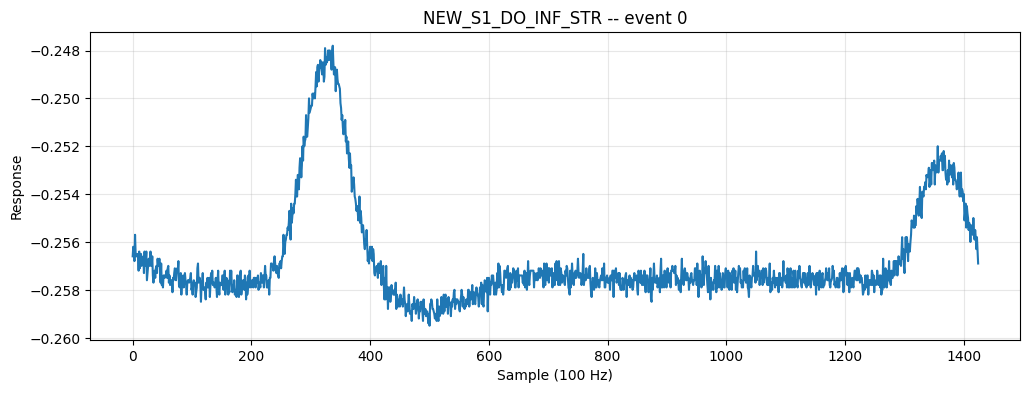

In [4]:
meta, waveform = reader.read_record(sensor, row_index=event_idx)
plot_waveform(waveform, title=f"{sensor} -- event {event_idx}")

## All 48 sensors -- grid view

Plot the same event index across every sensor to compare
acceleration and strain responses.

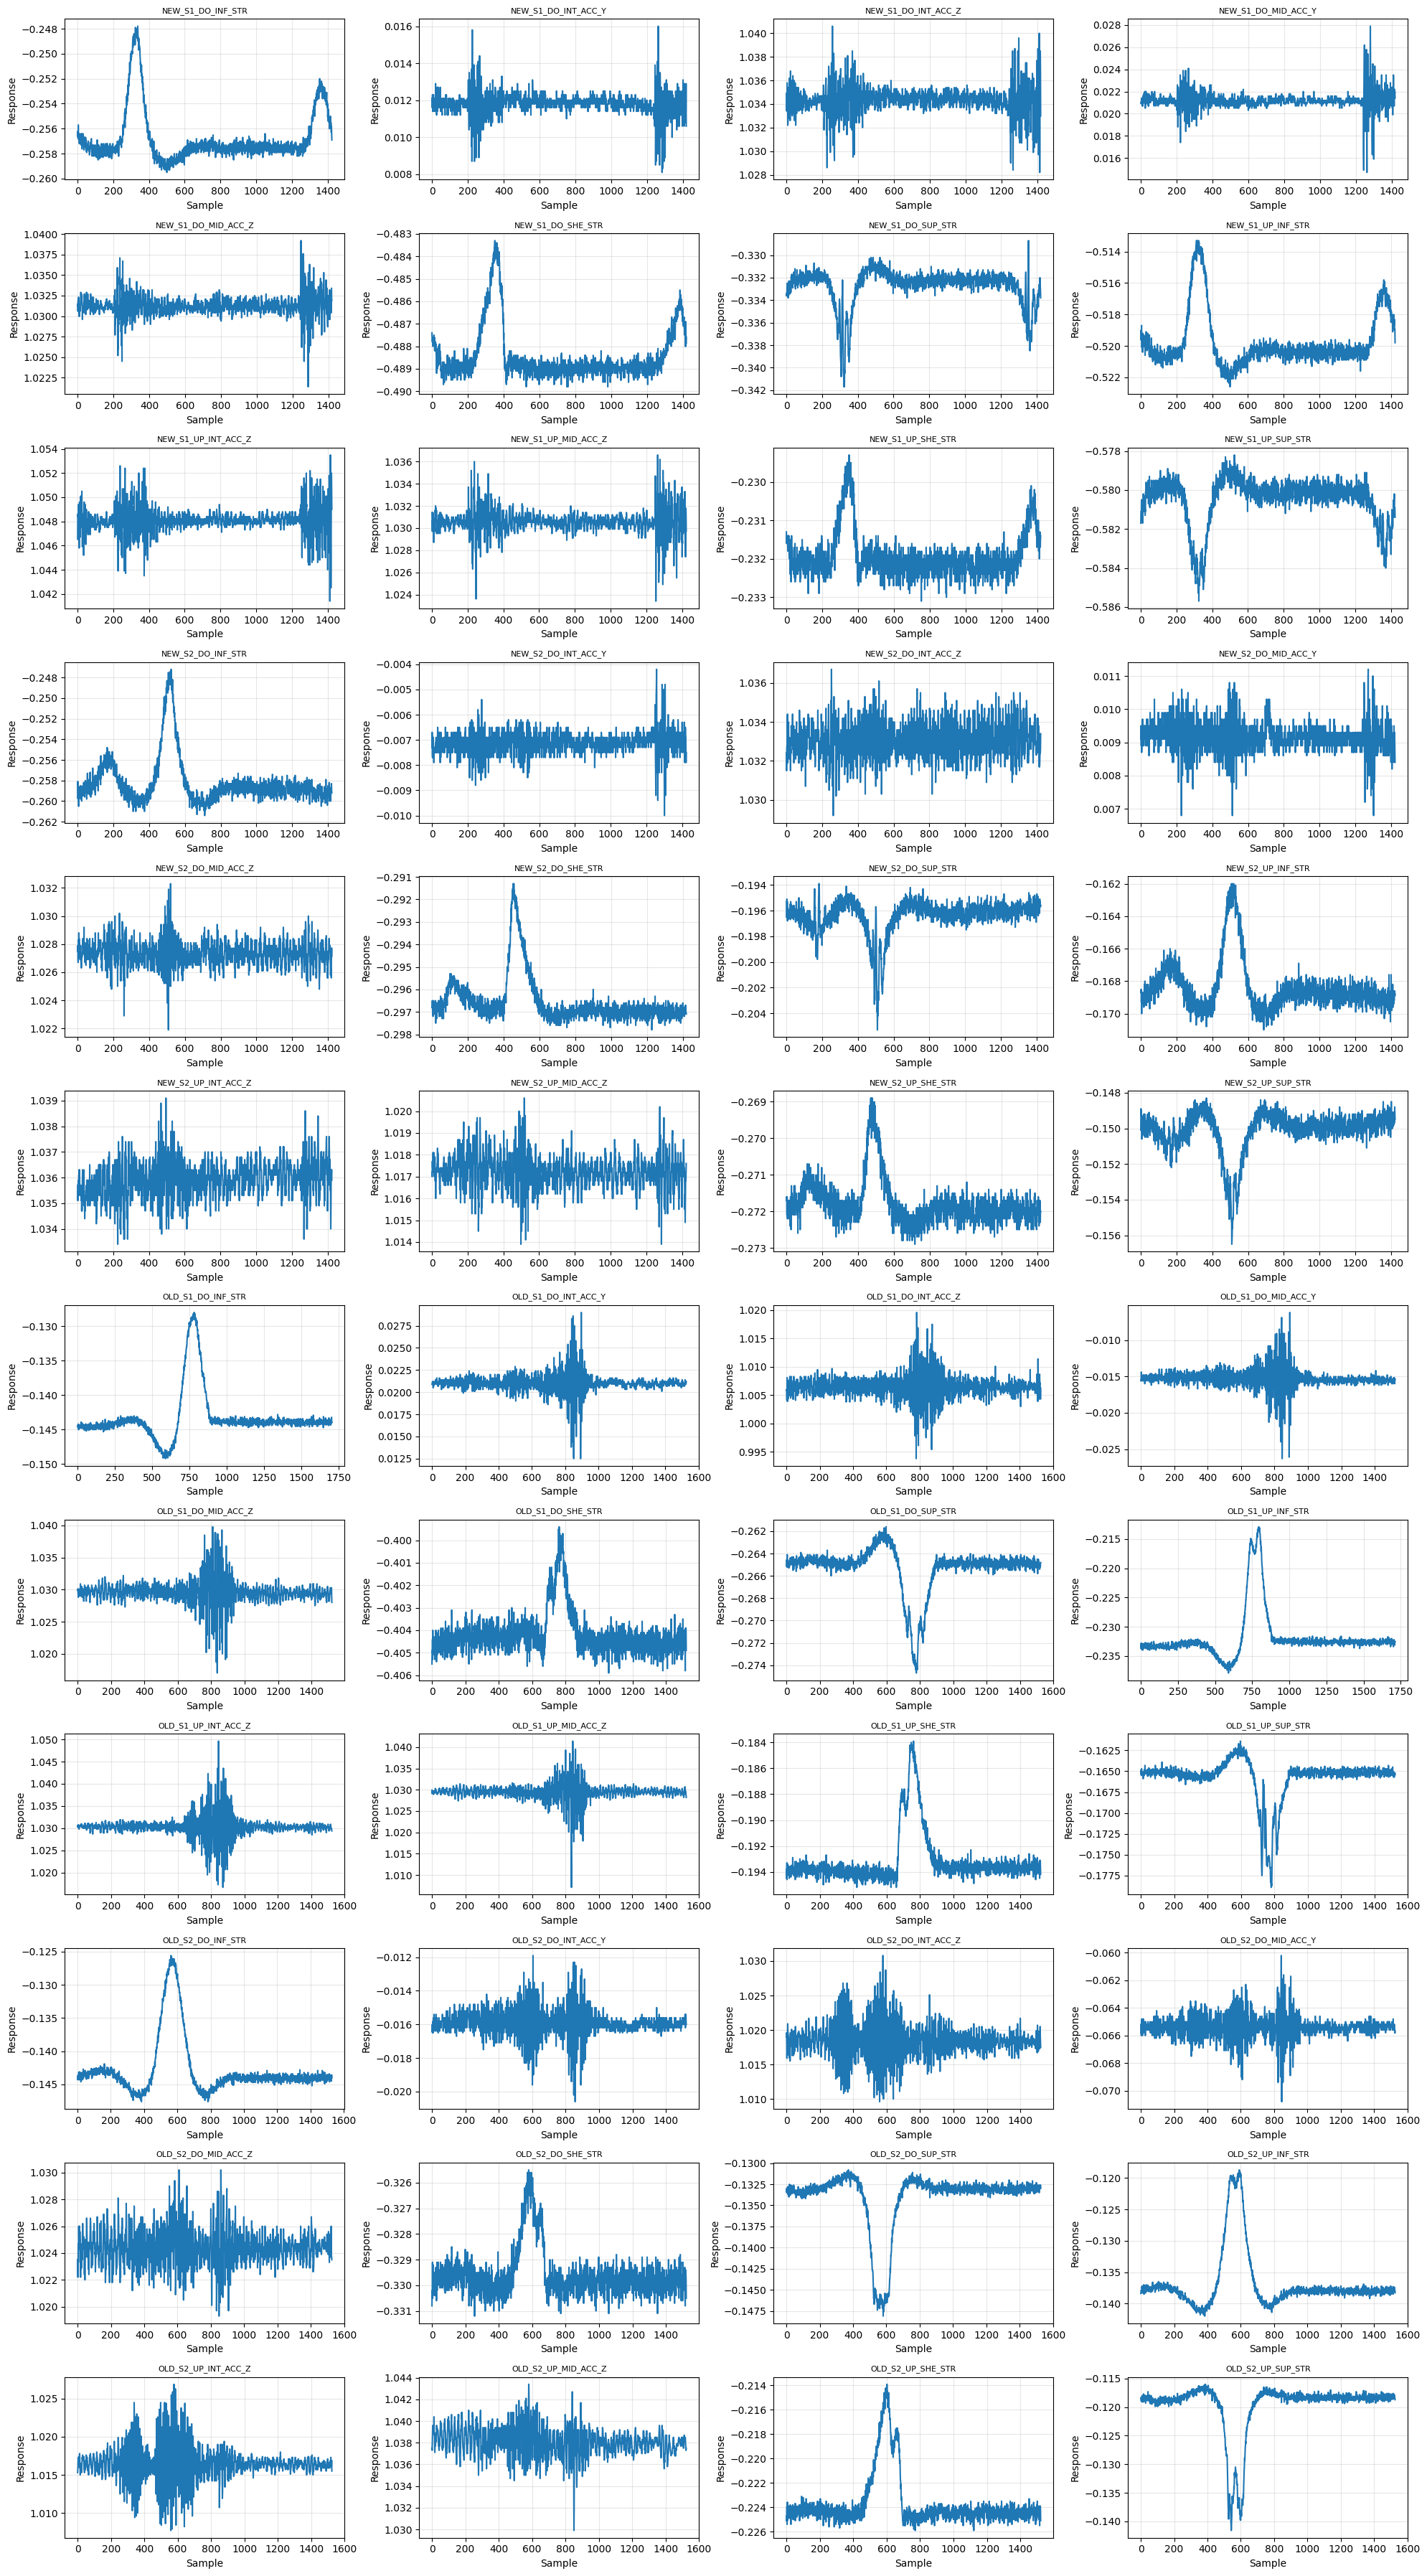

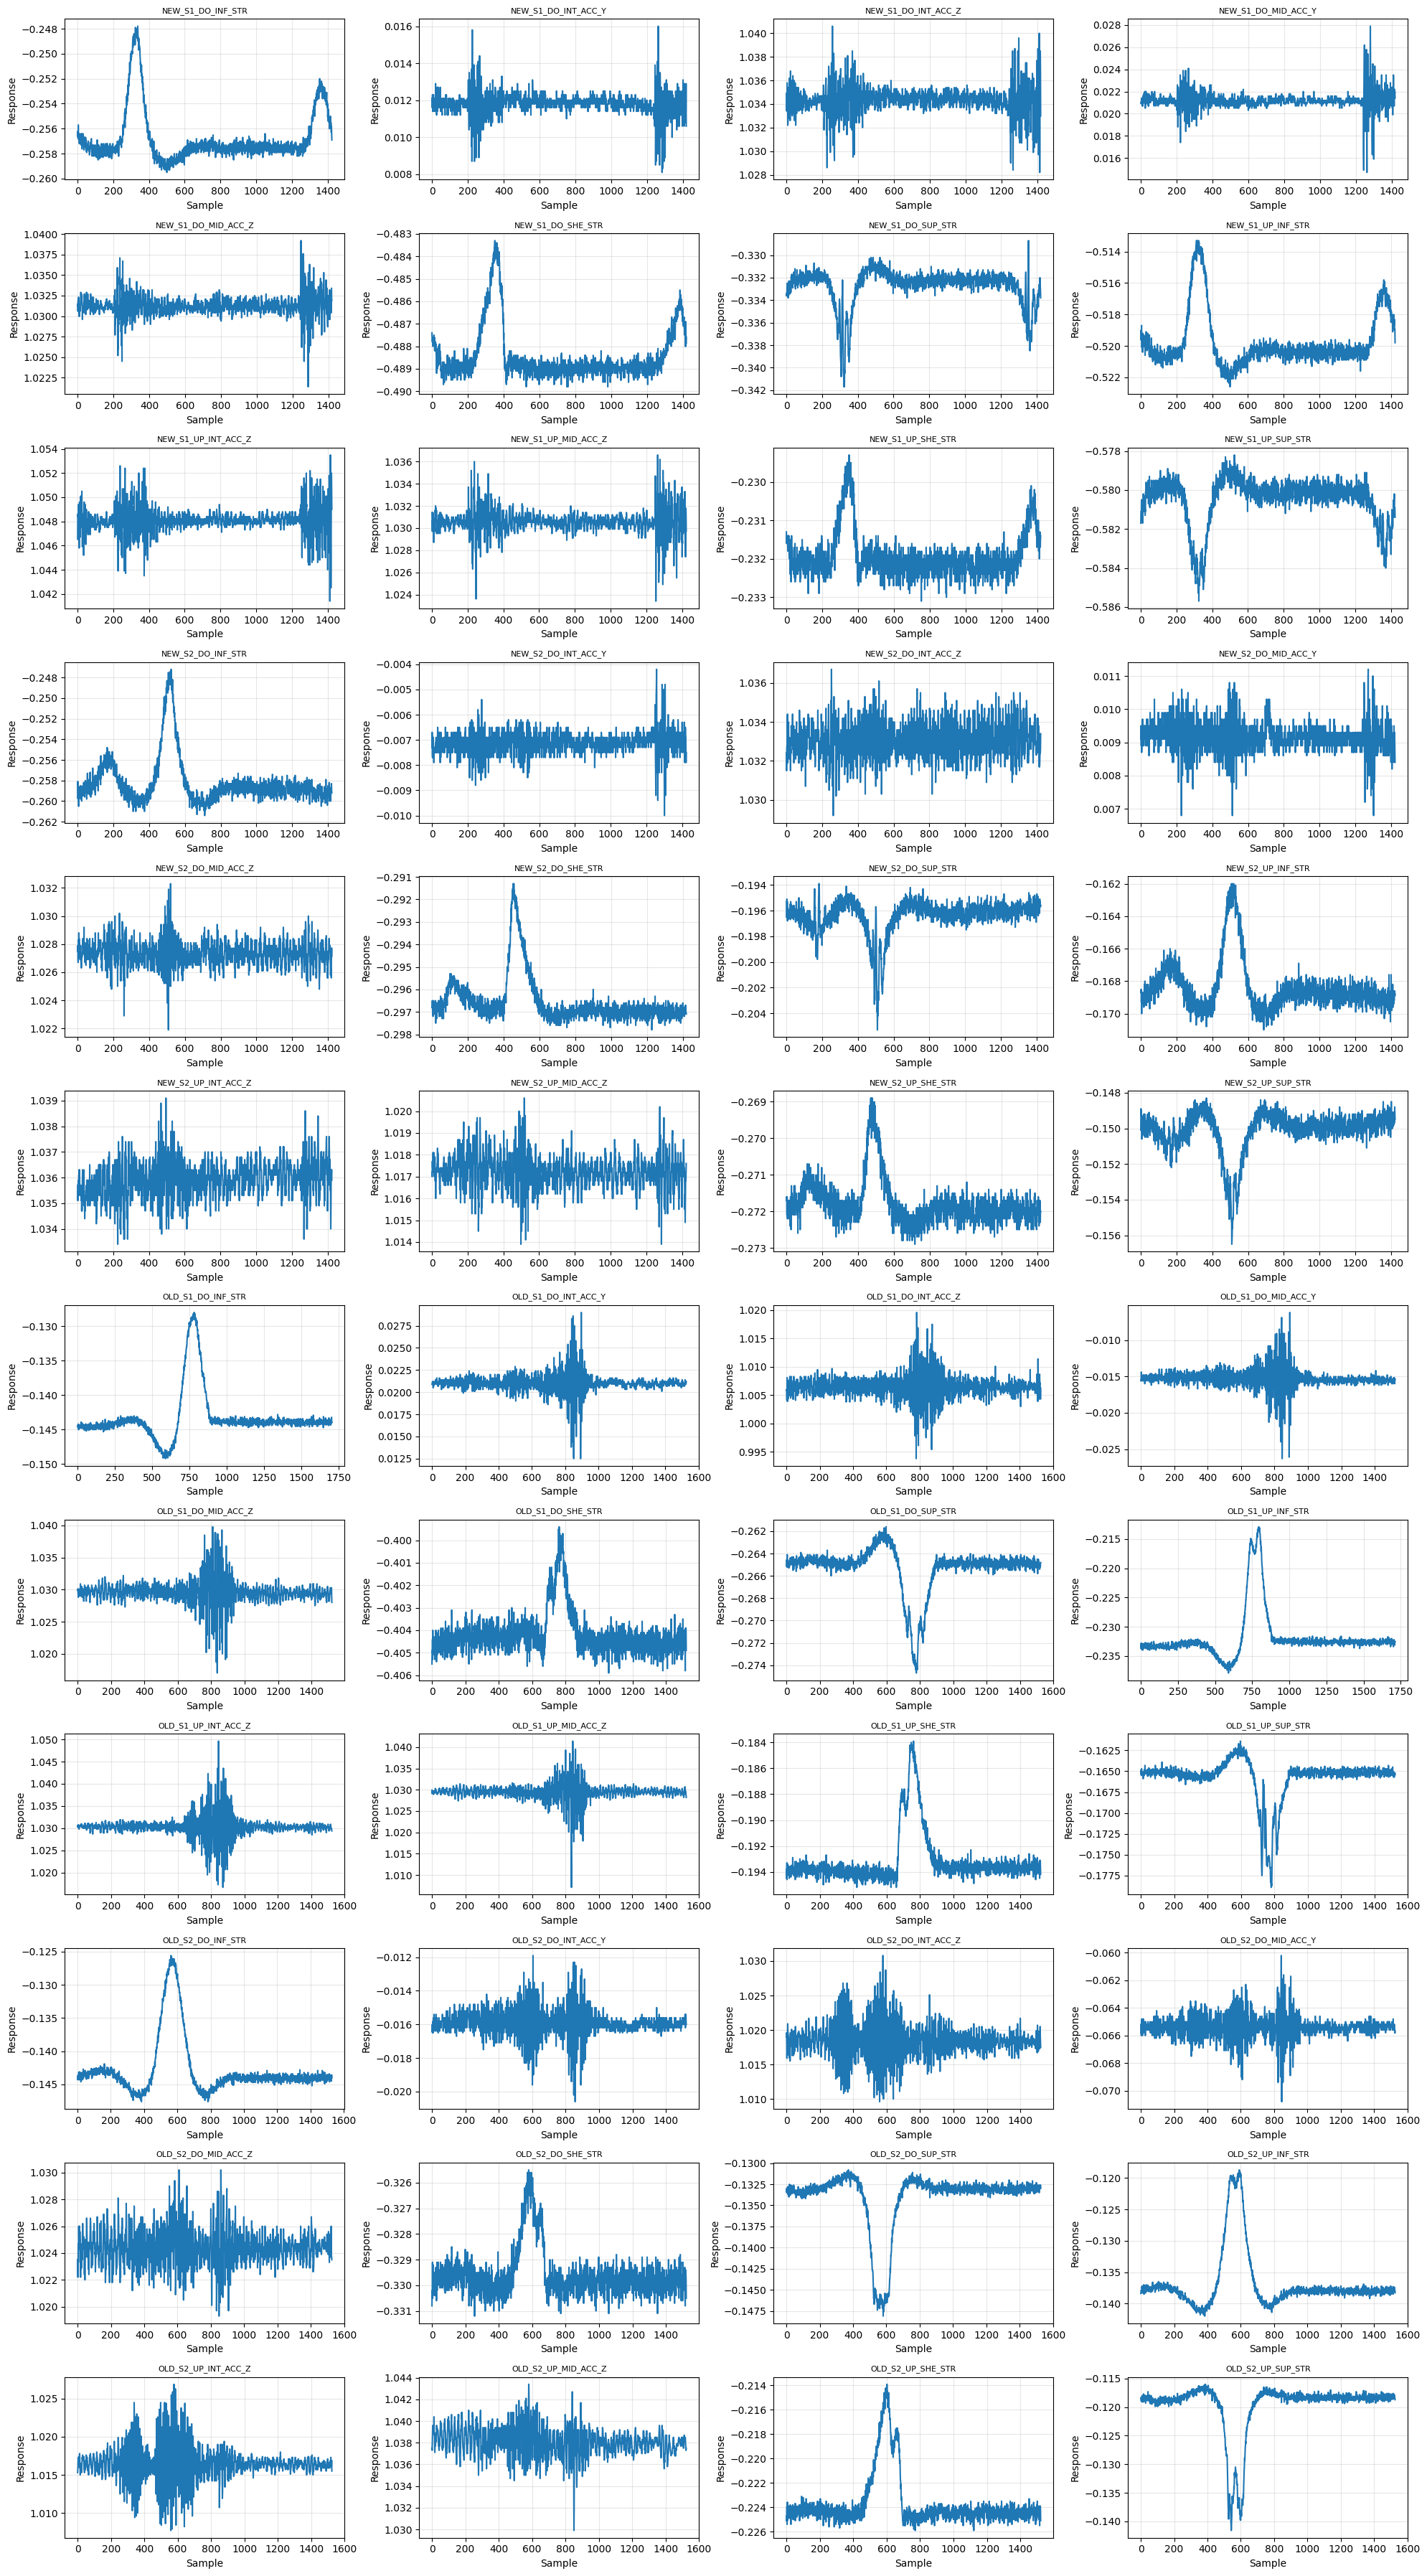

In [5]:
plot_sensor_grid(reader, event_idx=0)

## All sensors -- overlay view

Overlay every sensor's waveform on a single plot to see
relative magnitudes and timing.

<Axes: title={'center': 'All sensors -- event 0'}, xlabel='Sample (100 Hz)', ylabel='Response'>

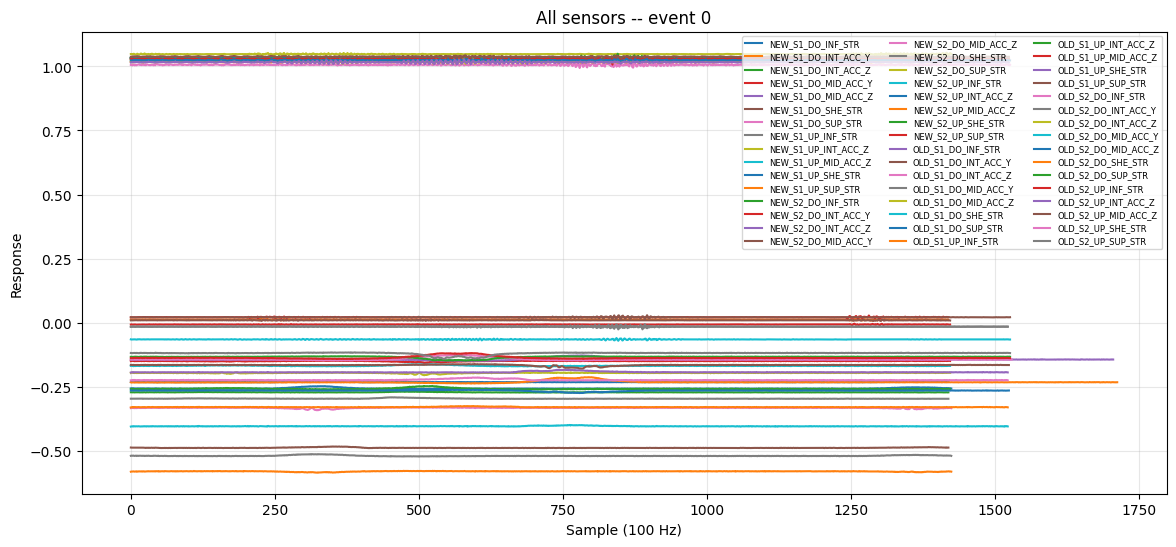

In [6]:
plot_sensor_overlay(reader, event_idx=0)

## Next steps

- `02_preprocessing.ipynb` -- filtering, baseline removal, temperature normalisation
- `03_feature_extraction.ipynb` -- time- and frequency-domain features
- `04_anomaly_detection.ipynb` -- unsupervised outlier and trend detection
- `05_health_scoring.ipynb` -- aggregate into a structural health score